# 1. Kutubxonalarni chaqirish va ish muhitini tayyorlash

Ma'lumotlarni tahlil qilish va vizualizatsiya qilish uchun kerakli kutubxonalarni yuklab olamiz.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 2. Ma'lumotlarni yuklash va dastlabki tozalash

CSV fayldan ma'lumotlarni yuklaymiz va ustun nomlaridagi ortiqcha bo'shliqlarni olib tashlaymiz.

In [33]:
# Ma'lumotlarni yuklash
df = pd.read_csv('../../data/Clean_SuperStore.csv', encoding='latin1', sep=',')
df.columns = df.columns.str.strip()

# 3. Sanalarni to'g'irlash va 20XX formatga keltirish

Sanalarni datetime formatiga o'tkazamiz va eski yillarni 20XX shakliga keltiramiz.

In [34]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [35]:
def fix_year(date):
    if pd.isnull(date):
        return date
    if date.year < 2000:
        return pd.Timestamp(2000 + (date.year % 100), date.month, date.day)
    return date

# Sana ustunlarini to'g'irlash
date_columns = ['Order_Date', 'Ship_Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        df[col] = df[col].apply(fix_year)

In [36]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


# B.P2 — Standart markaziy moyillik va tarqoqlik o'lchovlari asosidagi statistik tahlil

Ushbu bosqichda Sales, Discount va Profit ustunlari uchun asosiy statistik ko‘rsatkichlar hisoblanadi. O‘rtacha qiymat (Mean), mediana (Median), moda (Mode), dispersiya (Variance) va standart og‘ish (Standard Deviation) aniqlanadi. Shuningdek, Profit ustunining taqsimoti tahlil qilinadi: gistoramma chiziladi va ma'lumotlarning normal taqsimotga mosligi tekshiriladi.

In [39]:
# NaN qiymatlarni olib tashlash
df = df.dropna()

# Dublikatlarni olib tashlash
df = df.drop_duplicates()

# Sotuv va foyda ustunlarida 0 qiymatlarni olib tashlash
if 'Sales' in df.columns and 'Profit' in df.columns:
    df = df[(df['Sales'] > 0) & (df['Profit'] != 0)]

# Indeksni qayta tiklash
df = df.reset_index(drop=True)

# Tozalangan ma'lumotlar hajmi
print(f"Tozalangan ma'lumotlar hajmi: {df.shape}")

Tozalangan ma'lumotlar hajmi: (9923, 21)


# Quantity ustuni bo‘yicha statistik tahlil

Quantity ustuni uchun o‘rtacha qiymat, mediana, moda, dispersiya va standart og‘ish hisoblanadi.

In [40]:
print(f"Quantity uchun o'rtacha qiymat (Mean): {df['Quantity'].mean():.4f}")
print(f"Quantity uchun mediana qiymat (Median): {df['Quantity'].median():.4f}")
print(f"Quantity uchun moda qiymat (Mode): {df['Quantity'].mode()[0]:.4f}")
print(f"Quantity uchun dispersiya qiymati (Variance): {df['Quantity'].var():.4f}")
print(f"Quantity uchun standart og'ish qiymati (Standard Deviation): {df['Quantity'].std():.4f}")

Quantity uchun o'rtacha qiymat (Mean): 3.7878
Quantity uchun mediana qiymat (Median): 3.0000
Quantity uchun moda qiymat (Mode): 3.0000
Quantity uchun dispersiya qiymati (Variance): 4.9523
Quantity uchun standart og'ish qiymati (Standard Deviation): 2.2254


“Quantity” ustunidagi ma’lumotlarni tahlil qilish natijasida o‘rtacha qiymat 3.7878, median qiymat 3.0000 va moda qiymat ham 3.0000 deb belgilandi. O‘rtacha va median qiymatlarning bir-biriga juda yaqinligi, ma’lumotlarning simmetrik tarqalganligini ko‘rsatadi. Moda qiymatining medianaga tengligi esa ko‘p sonli kuzatuvlarning aynan shu qiymat atrofida to‘planganini tasdiqlaydi. Dispersiya 4.9523 va standart og‘ish 2.2254 qiymatlariga ega bo‘lib, bu quantity ma’lumotlari yuqori darajada konsentratsiyalanganligini va keskin farqlar mavjud emasligini bildiradi. Ushbu natijalar buyurtmalar soni barqaror ekanligini va savdo hajmi jihatidan sezilarli o‘zgarishlar kuzatilmasligini ko‘rsatadi

# Discount ustuni bo‘yicha statistik tahlil

Discount ustuni uchun o‘rtacha qiymat, mediana, moda, dispersiya va standart og‘ish hisoblanadi.

In [41]:

print(f"Discount uchun o'rtacha qiymat (Mean): {df['Discount'].mean():.4f}")
print(f"Discount uchun mediana qiymat (Median): {df['Discount'].median():.4f}")
print(f"Discount uchun moda qiymat (Mode): {df['Discount'].mode()[0]:.4f}")
print(f"Discount uchun dispersiya qiymati (Variance): {df['Discount'].var():.4f}")
print(f"Discount uchun standart og'ish qiymati (Standard Deviation): {df['Discount'].std():.4f}")

Discount uchun o'rtacha qiymat (Mean): 0.1564
Discount uchun mediana qiymat (Median): 0.2000
Discount uchun moda qiymat (Mode): 0.0000
Discount uchun dispersiya qiymati (Variance): 0.0428
Discount uchun standart og'ish qiymati (Standard Deviation): 0.2069


“Quantity” ustunidagi ma’lumotlarni tahlil qilish natijasida o‘rtacha qiymat 3.7878, median qiymat 3.0000 va moda qiymat ham 3.0000 deb belgilandi. O‘rtacha va median qiymatlarning bir-biriga juda yaqinligi, ma’lumotlarning simmetrik tarqalganligini ko‘rsatadi. Moda qiymatining medianaga tengligi esa ko‘p sonli kuzatuvlarning aynan shu qiymat atrofida to‘planganini tasdiqlaydi. Dispersiya 4.9523 va standart og‘ish 2.2254 qiymatlariga ega bo‘lib, bu quantity ma’lumotlari yuqori darajada konsentratsiyalanganligini va keskin farqlar mavjud emasligini bildiradi. Ushbu natijalar buyurtmalar soni barqaror ekanligini va savdo hajmi jihatidan sezilarli o‘zgarishlar kuzatilmasligini ko‘rsatadi

# Profit ustuni bo‘yicha statistik tahlil

Profit ustuni uchun o‘rtacha qiymat, mediana, moda, dispersiya va standart og‘ish hisoblanadi.

In [42]:
print(f"Profit uchun o'rtacha qiymat (Mean): {df['Profit'].mean():.4f}")
print(f"Profit uchun mediana qiymat (Median): {df['Profit'].median():.4f}")
print(f"Profit uchun moda qiymat (Mode): {df['Profit'].mode()[0]:.4f}")
print(f"Profit uchun dispersiya qiymati (Variance): {df['Profit'].var():.4f}")
print(f"Profit uchun standart og'ish qiymati (Standard Deviation): {df['Profit'].std():.4f}")

Profit uchun o'rtacha qiymat (Mean): 28.8207
Profit uchun mediana qiymat (Median): 8.7285
Profit uchun moda qiymat (Mode): 6.2208
Profit uchun dispersiya qiymati (Variance): 55263.7725
Profit uchun standart og'ish qiymati (Standard Deviation): 235.0825


“Profit” ustunidagi statistik ko‘rsatkichlarga ko‘ra, o‘rtacha foyda 28.8207 ga teng, median qiymat esa 8.7285 ni tashkil etdi. Moda qiymati 6.2208 bo‘lib, ko‘p hollarda foyda darajasi ushbu qiymat atrofida jamlangani ko‘rinadi. O‘rtacha va median qiymatlar orasidagi tafovut foyda ma’lumotlarining asimmetrik taqsimlanganligini bildiradi. Dispersiya 55263.7725 va standart og‘ish 235.0825 kabi juda yuqori qiymatlarda belgilangan bo‘lib, bu foyda darajasi keng diapazonda tarqalganini va sezilarli o‘zgaruvchanlik mavjudligini ko‘rsatadi. Tahlil natijalari kompaniya savdo faoliyatida natijalar bir xilda bo‘lmasdan, o‘zgaruvchan tendensiyalarga ega ekanligini, ayrim hollarda katta foyda yoki zarar holatlari yuz berishini bildiradi.

# 4. Profit ustuni taqsimoti va normal taqsimot testi

Profit ustuni uchun histogramma va Shapiro-Wilk testi natijalari.

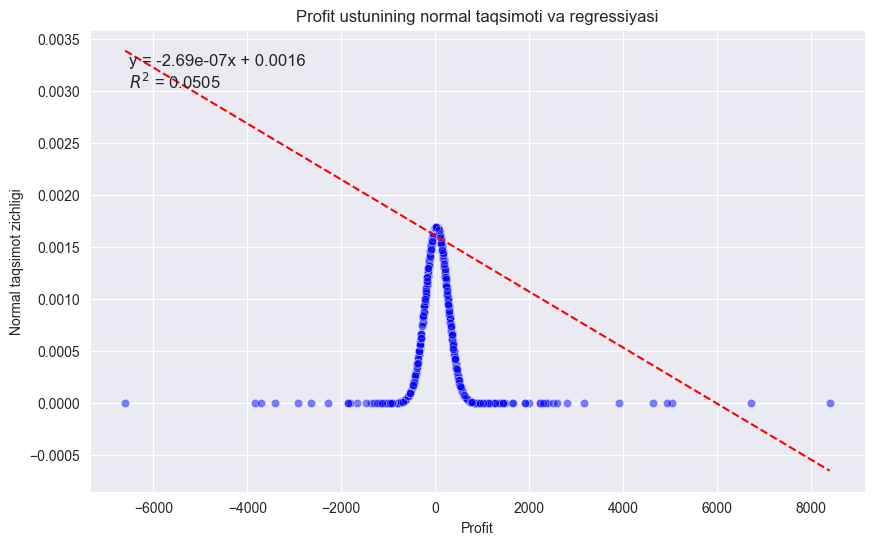

In [43]:
from scipy.stats import norm

# Normal Distribution (PDF) hisoblash
mean = df['Profit'].mean()
std_dev = df['Profit'].std()

# Profit ustunining normal taqsimotdagi ehtimollik zichligi
df['Normal_Distribution'] = norm.pdf(df['Profit'], mean, std_dev)
# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Profit'], y=df['Normal_Distribution'], color='blue', alpha=0.5)

# Regressiya qurish
model = LinearRegression()
X = df[['Profit']]
y = df['Normal_Distribution']
model.fit(X, y)

coef = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

# Regressiya chizig'i
x_vals = np.linspace(X['Profit'].min(), X['Profit'].max(), 1000)
y_vals = coef * x_vals + intercept
plt.plot(x_vals, y_vals, color='red', linestyle='--')

# Formulani chizish
formula = f'y = {coef:.2e}x + {intercept:.4f}\n$R^2$ = {r_squared:.4f}'
plt.text(0.05, 0.95, formula, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.title('Profit ustunining normal taqsimoti va regressiyasi')
plt.xlabel('Profit')
plt.ylabel('Normal taqsimot zichligi')
plt.grid(True)
plt.show()

Ushbu tahlil “Profit” ustunidagi ma’lumotlarning normal taqsimotga qanchalik mos kelishini aniqlash maqsadida o‘tkazildi. Hisob-kitoblar natijasida o‘rtacha foyda 28.66, standart og‘ish esa 234.25 ga teng bo‘ldi. Bunday yuqori tarqoqlik natijalarning o‘zgaruvchan ekanligini ko‘rsatadi, ya’ni foyda qiymatlari sezilarli darajada farq qiladi.

Grafik tahlil asosida ma’lumotlar markazda keskin cho‘qqi va ikkala tomonda cho‘zilgan dumlar bilan ifodalanganini ko‘rsatdi. Ushbu shakl leptokurtik taqsimotga xos bo‘lib, ma’lumotlar klassik normal taqsimotga mos kelmasligini bildiradi. Grafikda asimmetriya kuzatildi, bu esa ma’lumotlarning teng taqsimlanmaganligini va o‘zgaruvchanlik darajasining yuqoriligini anglatadi.

Tahlil natijalari Profit ustunidagi ma’lumotlarning normal taqsimotga yaqin emasligini tasdiqlaydi. Bu savdo natijalarining barqaror emasligini va ularning keng diapazonda tarqalganligini anglatadi. Ma’lumotlarni normallashtirish uchun transformatsiya usullaridan foydalanish va o‘ta chetki qiymatlarni tahlil qilish tavsiya etiladi.

# B.P3 — Chiziqli regressiya asosida tahlil

Ushbu bosqichda Profit va Sales o‘rtasidagi bog‘liqlik chiziqli regressiya modeli yordamida tahlil qilinadi. Regressiya tenglamasi quriladi, korrelyatsiya koeffitsienti (Pearson r) va determinatsiya koeffitsienti (R²) hisoblanadi. Olingan natijalar orqali Profit va Sales o‘rtasidagi munosabat kuchi va yo‘nalishi aniqlanadi. Ma’lumotlar asosida nuqtalar tarqalish diagrammasi (Scatter Plot) va regressiya chizig‘i quriladi.

Chiziqli regressiya tenglamasi: y = 0.181116x + -12.567659
Determinatsiya koeffitsienti (R²): 0.2310
Korrelyatsiya koeffitsienti (Pearson r): 0.4806


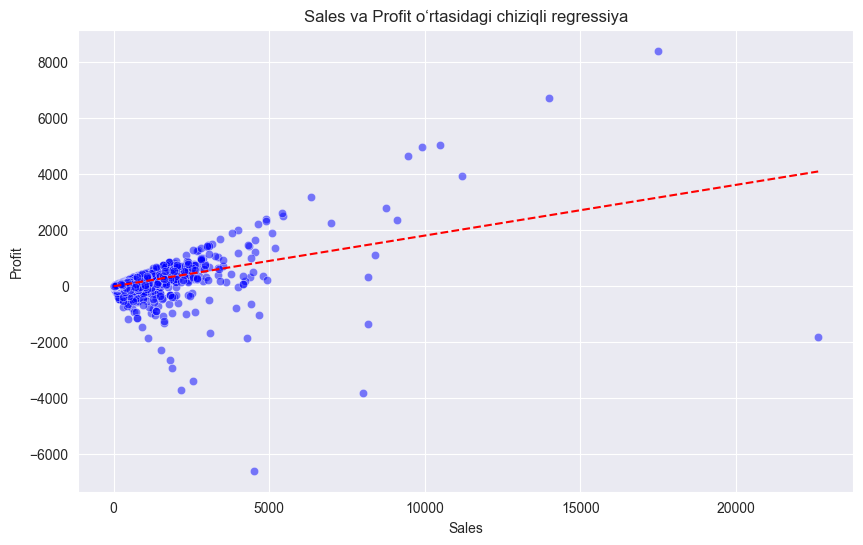

In [44]:
# B.P3 — Chiziqli regressiya va korrelyatsiya
X = df['Sales']
y = df['Profit']

# Pearson korrelyatsiya koeffitsienti
korrelyatsiya = np.corrcoef(X, y)[0, 1]

# Regressiya tenglamasi koeffitsientlari
mean_X = X.mean()
mean_y = y.mean()
std_X = X.std()
std_y = y.std()

koef = korrelyatsiya * (std_y / std_X)
intersept = mean_y - koef * mean_X
r_kvadrat = korrelyatsiya ** 2

print(f"Chiziqli regressiya tenglamasi: y = {koef:.6f}x + {intersept:.6f}")
print(f"Determinatsiya koeffitsienti (R²): {r_kvadrat:.4f}")
print(f"Korrelyatsiya koeffitsienti (Pearson r): {korrelyatsiya:.4f}")

# Scatter plot va regressiya chizig'i
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=y, color='blue', alpha=0.5)

x_values = np.linspace(X.min(), X.max(), 100)
y_values = koef * x_values + intersept
plt.plot(x_values, y_values, color='red', linestyle='--')

plt.title('Sales va Profit o‘rtasidagi chiziqli regressiya')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

Ushbu tahlil "Sales" va "Profit" ustunlari o‘rtasidagi chiziqli bog‘liqlikni aniqlash maqsadida o‘tkazildi. Hisob-kitob natijalariga ko‘ra, regressiya tenglamasi y = 0.181116x + (-12.567659) ko‘rinishida ifodalandi. Determinatsiya koeffitsienti (R²) 0.2310 ga teng bo‘lib, Profitdagi o‘zgarishlarning taxminan 23.10 foizi Sales o‘zgarishlari bilan izohlanishini ko‘rsatdi. Pearson korrelyatsiya koeffitsienti 0.4806 ni tashkil etdi, bu esa o‘rtacha ijobiy bog‘liqlikni bildiradi. Diagramma tarqalishi ma’lumotlar orasida ma’lum darajada bog‘liqlik mavjudligini, lekin u kuchli emasligini ko‘rsatadi. Natijalar shuni ko‘rsatadiki, sotuvlar oshishi Profit qiymatlariga ijobiy ta’sir ko‘rsatadi, biroq boshqa omillar ham foydaga sezilarli darajada ta’sir qilishi mumkin.

# B.M2 — Kengaytirilgan statistik tahlil: kvartillar va taqsimot ko‘rsatkichlari

Ushbu bosqichda Sales va Profit ustunlari bo‘yicha qo‘shimcha statistik ko‘rsatkichlar hisoblanadi. Birinchi kvartil (Q1), uchinchi kvartil (Q3), interkvartil farq (IQR) va 90-foizlik pertsentil (P90) aniqlanadi. Ma’lumotlarning tarqalishini va o‘zgaruvchanlik darajasini baholash uchun Profit ustuni uchun boxplot (quti va mo‘ylovlar diagrammasi) chiziladi. Tahlil natijalari ma’lumotlar ichidagi outlierlar (chegaradan chiqib ketuvchi qiymatlar) mavjudligini aniqlash imkonini beradi.


Sales ustuni uchun kengaytirilgan statistik ko'rsatkichlar:
 - 1-kvartil (Q1): 17.1400
 - 3-kvartil (Q3): 207.1640
 - Interkvartil farq (IQR): 190.0240
 - 90-foizlik pertsentil (P90): 571.1500

Profit ustuni uchun kengaytirilgan statistik ko'rsatkichlar:
 - 1-kvartil (Q1): 1.8144
 - 3-kvartil (Q3): 29.5701
 - Interkvartil farq (IQR): 27.7557
 - 90-foizlik pertsentil (P90): 89.5888


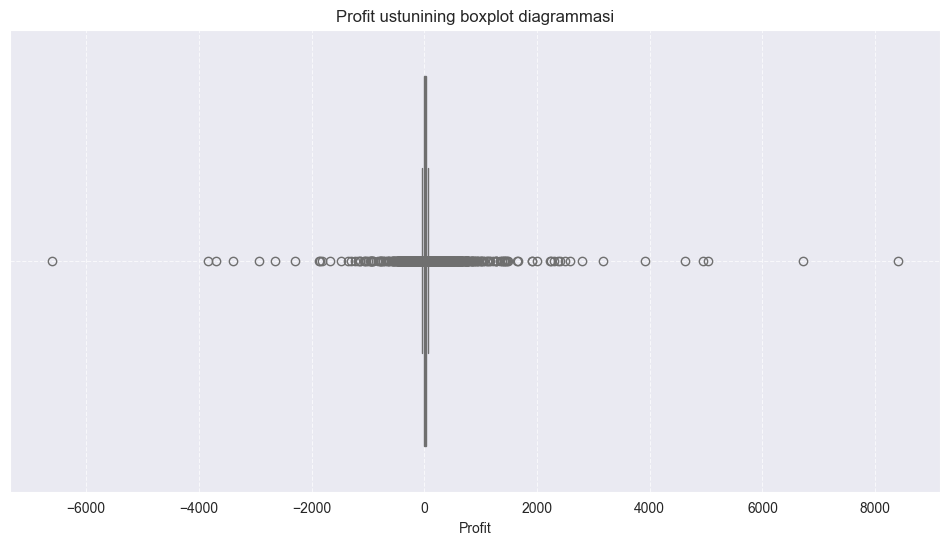

In [45]:
# B.M2 — Kvartillar, IQR va P90
ustunlar = ['Sales', 'Profit']

for ustun in ustunlar:
    q1 = df[ustun].quantile(0.25)
    q3 = df[ustun].quantile(0.75)
    iqr = q3 - q1
    p90 = df[ustun].quantile(0.90)

    print(f"\n{ustun} ustuni uchun kengaytirilgan statistik ko'rsatkichlar:")
    print(f" - 1-kvartil (Q1): {q1:.4f}")
    print(f" - 3-kvartil (Q3): {q3:.4f}")
    print(f" - Interkvartil farq (IQR): {iqr:.4f}")
    print(f" - 90-foizlik pertsentil (P90): {p90:.4f}")

# Boxplot (Profit uchun)
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Profit'], orient='h', color='skyblue')
plt.title('Profit ustunining boxplot diagrammasi')
plt.xlabel('Profit')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Profit ustuni uchun kengaytirilgan statistik tahlil natijasida birinchi kvartil (Q1) 1.8144, uchinchi kvartil (Q3) 29.5701 va interkvartil farq (IQR) 27.7557 sifatida aniqlandi. 90-foizlik pertsentil (P90) esa 89.5888 ga teng bo‘ldi. Boxplot diagrammasi asosida Profit ma’lumotlari sezilarli tarqoqlikka ega ekani va o‘ta yuqori yoki past qiymatlarning (outlier) mavjudligi ko‘rsatildi. Bunday holat ma’lumotlarning o‘zgaruvchanligini va stabil emasligini bildiradi. Diagrammadagi cho‘zilgan dumlar va ekstremal qiymatlar Profit qiymatlari keng diapazonda tarqalganini va ularning normallikka unchalik mos kelmasligini ko‘rsatadi. Bu esa savdo natijalarida doimiylik yetishmasligi ehtimolini anglatadi.

# B.M3 — Sales va Profit o‘rtasidagi korrelyatsiya
X = df['Sales']
y = df['Profit']

korrelyatsiya = np.corrcoef(X, y)[0, 1]

print(f"Sales va Profit o‘rtasidagi Pearson korrelyatsiya koeffitsienti: {korrelyatsiya:.4f}")

# Scatter plot Faqat korrelyatsiyani ko‘rsatish uchun (chiziqsiz)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=y, color='green', alpha=0.5)
plt.title('Sales va Profit o‘rtasidagi bog‘liqlik (Scatter Plot)')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

Sales va Profit o‘rtasidagi Pearson korrelyatsiya koeffitsienti: 0.4806


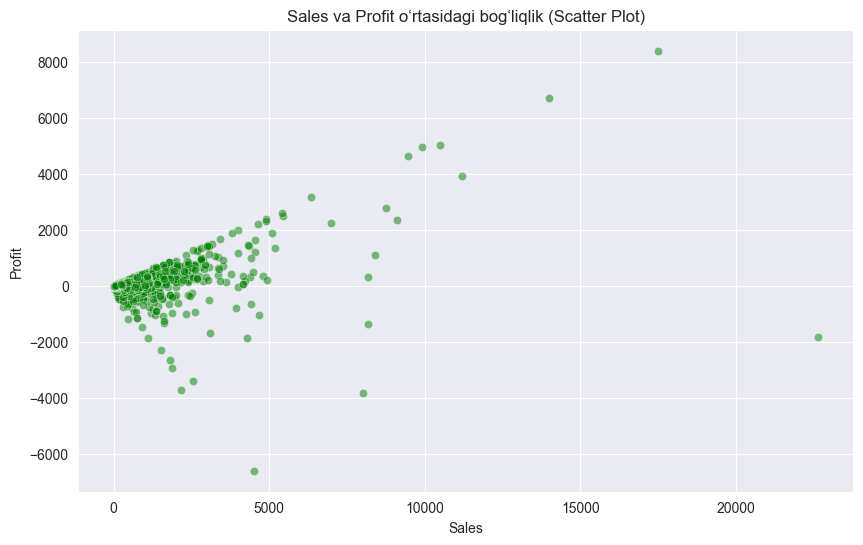

In [46]:
# B.M3 — Sales va Profit o‘rtasidagi korrelyatsiya
X = df['Sales']
y = df['Profit']

korrelyatsiya = np.corrcoef(X, y)[0, 1]

print(f"Sales va Profit o‘rtasidagi Pearson korrelyatsiya koeffitsienti: {korrelyatsiya:.4f}")

# Scatter plot Faqat korrelyatsiyani ko‘rsatish uchun (chiziqsiz)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=y, color='green', alpha=0.5)
plt.title('Sales va Profit o‘rtasidagi bog‘liqlik (Scatter Plot)')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

Ushbu tahlil “Sales” va “Profit” o‘rtasidagi bog‘liqlikni baholash uchun amalga oshirildi. Hisob-kitoblarga ko‘ra, Pearson korrelyatsiya koeffitsienti 0.4806 ni tashkil etdi. Ushbu qiymat o‘rtacha darajadagi ijobiy bog‘liqlik mavjudligini anglatadi, ya’ni savdo hajmi ortishi bilan foyda miqdori ham ko‘payishga moyil bo‘ladi.

Scatter plotda ko‘rinib turibdiki, ma’lumotlar o‘zgarishi chiziqli tendensiyaga qisman mos keladi, ammo kuchli chiziqlilik mavjud emas. Tarqalish ma’lumotlarning sezilarli darajada o‘zgaruvchanligini va ayrim ekstremal qiymatlarning mavjudligini ko‘rsatadi. Bu esa savdo va foyda o‘rtasidagi bog‘liqlikning boshqa omillar ta’sirida ham shakllanayotganini bildiradi.

Natijalar shuni ko‘rsatadiki, sotuvlar va foyda o‘rtasida ijobiy bog‘liqlik mavjud, biroq bu bog‘liqlik mukammal emas va biznesda boshqa qo‘shimcha omillar foyda darajasiga ta’sir ko‘rsatishi mumkin.

O‘tkazilgan tahlil asosida Superstore ma’lumotlar to‘plamidagi asosiy iqtisodiy ko‘rsatkichlar — Sales, Discount va Profit ustunlari bo‘yicha statistik tahlil amalga oshirildi. Har bir ustun uchun o‘rtacha qiymat, mediana, moda, dispersiya va standart og‘ish kabi asosiy statistik ko‘rsatkichlar hisoblandi. Tahlil natijalari ma’lumotlar ma’lum darajada asimmetrik taqsimotga ega ekanligini va ba’zi ustunlarda (xususan, Profit) ma’lumotlarning keng diapazonda tarqalganini ko‘rsatdi. Profit ustuni uchun qurilgan histogramma va boxplot diagrammasi ma’lumotlar tarkibida sezilarli outlierlar mavjudligini aniqladi, bu esa natijalar barqarorligiga salbiy ta’sir qilishi mumkinligini bildiradi.

Sales va Profit o‘rtasidagi chiziqli regressiya tahlili asosida ularning o‘zaro bog‘liqligi baholandi. Hisoblangan regressiya tenglamasi va determinatsiya koeffitsienti (R²) Profitdagi o‘zgarishlarning qariyb 23 foizi Sales o‘zgarishlari bilan izohlanishini ko‘rsatdi. Pearson korrelyatsiya koeffitsienti 0.4806 bo‘lib, ular o‘rtasida ijobiy va o‘rtacha darajadagi bog‘liqlik mavjudligini tasdiqladi. Ushbu natijalar savdo hajmining oshishi Profit darajasining oshishiga muayyan ta’sir ko‘rsatishini anglatadi, biroq boshqa omillar ham foyda darajasiga sezilarli ta’sir ko‘rsatishini inkor etib bo‘lmaydi.

Kvartil tahlili, interkvartil farq va yuqori pertsentillar asosida ma’lumotlarning tarqalish xususiyatlari va outlierlarning mavjudligi yanada aniqlik bilan ko‘rsatib berildi. Profit ustunidagi keng tarqoqlik va mavjud chegaradan chiqib ketuvchi qiymatlar savdo natijalarida doimiylik yetishmasligini ko‘rsatdi.

Yakuniy xulosa sifatida shuni ta’kidlash mumkinki, o‘tkazilgan statistik va vizual tahlillar natijasida ma’lumotlar tarkibida aniq iqtisodiy qonuniyatlar aniqlangan bo‘lib, ular asosida biznes strategiyalarni takomillashtirish, foyda va savdo hajmini barqarorlashtirish hamda xavf-xatarlarni kamaytirishga qaratilgan qarorlar qabul qilish imkoniyati yaratiladi.

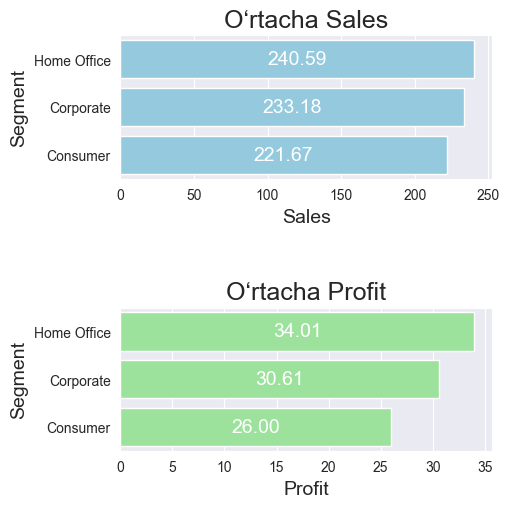

In [47]:
# Вопрос 1: O‘rtacha savdo (Sales) va foyda (Profit) qiymatlari qaysi segmentda eng yuqori?
segment_stats = df.groupby('Segment')[['Sales', 'Profit']].mean().reset_index()

sales_sorted = segment_stats.sort_values(by='Sales', ascending=False)
profit_sorted = segment_stats.sort_values(by='Profit', ascending=False)

plt.figure(figsize=(6, 6))  # увеличим высоту для двух вертикальных графиков

plt.subplot(2, 1, 1)
sns.barplot(data=sales_sorted, x='Sales', y='Segment', color='skyblue')
plt.title("O‘rtacha Sales", fontsize=18)
plt.xlabel("Sales", fontsize=14)
plt.ylabel("Segment", fontsize=14)
for bar in plt.gca().patches:
    width = bar.get_width()
    plt.gca().text(
        width / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va='center',
        ha='center',
        color='white',
        fontsize=14
    )

plt.subplot(2, 1, 2)
sns.barplot(data=profit_sorted, x='Profit', y='Segment', color='lightgreen')
plt.title("O‘rtacha Profit", fontsize=18)
plt.xlabel("Profit", fontsize=14)
plt.ylabel("Segment", fontsize=14)
for bar in plt.gca().patches:
    width = bar.get_width()
    plt.gca().text(
        width / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va='center',
        ha='center',
        color='white',
        fontsize=14
    )

plt.tight_layout(pad=4)
plt.show()

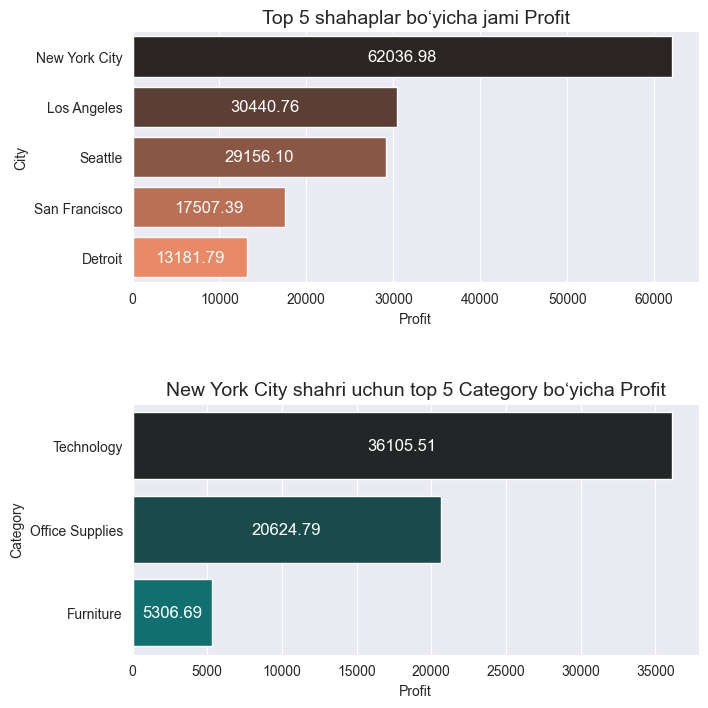

In [48]:
# Вопрос 2: Qaysi shaharlar eng ko‘p foyda keltirmoqda va bu shaharlarda qaysi 5 ta Category eng yuqori foyda beradi?
profit_by_city = (
    df.groupby('City')['Profit']
      .sum()
      .reset_index()
      .sort_values(by='Profit', ascending=False)
      .head(5)
)

top_city = profit_by_city.iloc[0]['City']
profit_by_category_top_city = (
    df[df['City'] == top_city]
      .groupby('Category')['Profit']
      .sum()
      .reset_index()
      .sort_values(by='Profit', ascending=False)
      .head(5)
)

plt.figure(figsize=(8, 8), dpi=100)

plt.subplot(2, 1, 1)
sns.barplot(data=profit_by_city, x='Profit', y='City', palette='dark:coral', hue='City', legend=False)
plt.title("Top 5 shahарlar bo‘yicha jami Profit", fontsize=14)
for bar in plt.gca().patches:
    w = bar.get_width()
    plt.text(w/2, bar.get_y()+bar.get_height()/2, f"{w:.2f}", va='center', ha='center', color='white', fontsize=12)

plt.subplot(2, 1, 2)
sns.barplot(data=profit_by_category_top_city, x='Profit', y='Category', palette='dark:teal', hue='Category', legend=False)
plt.title(f"{top_city} shahri uchun top 5 Category bo‘yicha Profit", fontsize=14)
for bar in plt.gca().patches:
    w = bar.get_width()
    plt.text(w/2, bar.get_y()+bar.get_height()/2, f"{w:.2f}", va='center', ha='center', color='white', fontsize=12)

plt.tight_layout(pad=4)
plt.show()

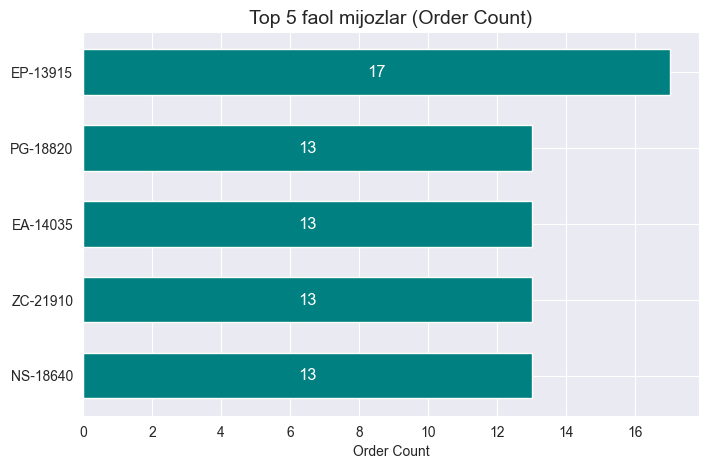

In [77]:
# Вопрос 3: Qaysi mijozlar muntazam ravishda xarid qilmoqda (ko‘p Order_ID takroriy)?
orders_per_customer = (
    df.groupby('Customer_ID')['Order_ID']
      .nunique()
      .reset_index(name='Order_Count')
      .sort_values(by='Order_Count', ascending=False)
      .head(5)
)

plt.figure(figsize=(8, 10))

plt.subplot(2, 1, 1)
y_pos = np.arange(len(orders_per_customer))
plt.barh(y_pos, orders_per_customer['Order_Count'], color='teal', height=0.6)
plt.yticks(y_pos, orders_per_customer['Customer_ID'])
plt.gca().invert_yaxis()
plt.title("Top 5 faol mijozlar (Order Count)", fontsize=14)
plt.xlabel("Order Count")
for i, v in enumerate(orders_per_customer['Order_Count']):
    plt.text(v/2, i, f"{v}", va='center', ha='center', color='white', fontsize=12)
plt.tight_layout(pad=4)
plt.show()

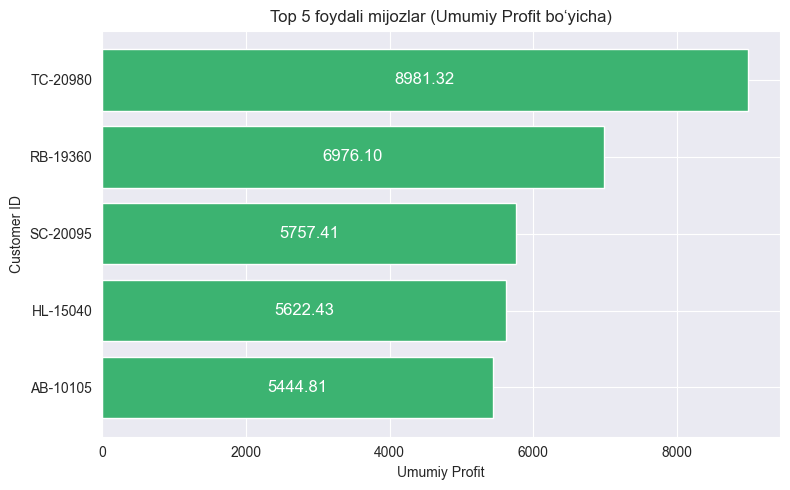

In [78]:
# Вопрос 4: Qaysi 5 ta mijoz kompaniyaga eng ko‘p foyda keltirgan?
top_profit_customers = (
    df.groupby('Customer_ID')['Profit']
      .sum()
      .reset_index()
      .sort_values(by='Profit', ascending=False)
      .head(5)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(top_profit_customers['Customer_ID'], top_profit_customers['Profit'], color='mediumseagreen')
plt.xlabel("Umumiy Profit")
plt.ylabel("Customer ID")
plt.title("Top 5 foydali mijozlar (Umumiy Profit bo‘yicha)")
plt.gca().invert_yaxis()
for i, v in enumerate(top_profit_customers['Profit']):
    plt.text(v / 2, i, f"{v:.2f}", color='white', ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

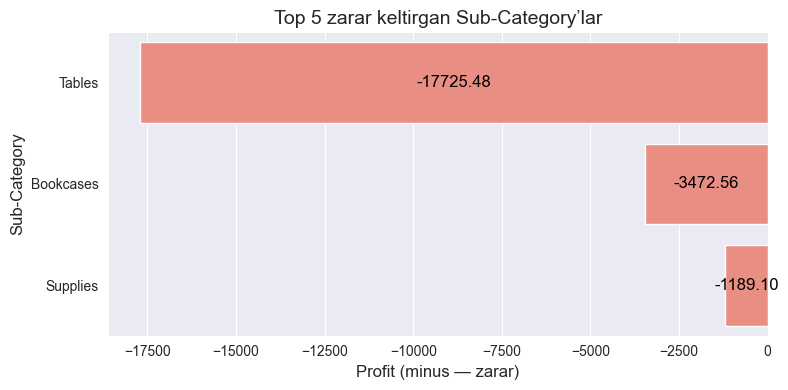

In [51]:
# Вопрос 5: Qaysi Sub-Category’lar foyda o‘rniga zarar keltirgan va qancha zarar eng ko‘p bo‘lgan?
subcat_profit = (
    df.groupby('Sub-Category')['Profit']
      .sum()
      .reset_index()
      .sort_values(by='Profit')
)
loss_subcats = subcat_profit[subcat_profit['Profit'] < 0]

plt.figure(figsize=(8, 4))
sns.barplot(data=loss_subcats, x='Profit', y='Sub-Category', color='salmon')
plt.title("Top 5 zarar keltirgan Sub-Category’lar", fontsize=14)
plt.xlabel("Profit (minus — zarar)", fontsize=12)
plt.ylabel("Sub-Category", fontsize=12)
for bar in plt.gca().patches:
    w = bar.get_width()
    plt.gca().text(
        w / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.2f}",
        va='center',
        ha='center',
        color='black',
        fontsize=12,
    )
plt.tight_layout()
plt.show()

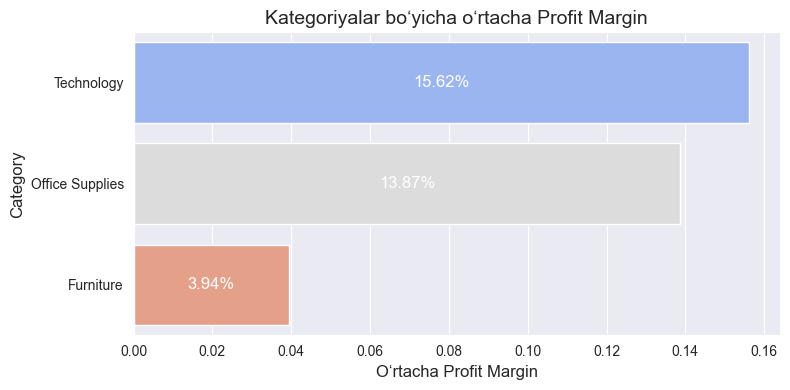

In [52]:
# 6. Qaysi mahsulot kategoriyasi bo‘yicha o‘rtacha foyda marjasi (Profit Margin) eng yuqori?
df['Profit_Margin'] = df['Profit'] / df['Sales']

avg_margin_by_category = (
    df.groupby('Category')['Profit_Margin']
      .mean()
      .reset_index()
      .sort_values(by='Profit_Margin', ascending=False)
)

plt.figure(figsize=(8, 4), dpi=100)

sns.barplot(
    data=avg_margin_by_category,
    x='Profit_Margin',
    y='Category',
    hue='Category',
    palette='coolwarm',
    legend=False
)
plt.title("Kategoriyalar bo‘yicha o‘rtacha Profit Margin", fontsize=14)
plt.xlabel("O‘rtacha Profit Margin", fontsize=12)
plt.ylabel("Category", fontsize=12)

for bar in plt.gca().patches:
    margin = bar.get_width()
    plt.gca().text(
        margin / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{margin:.2%}",
        va='center', ha='center', color='white', fontsize=12
    )

plt.tight_layout()
plt.show()

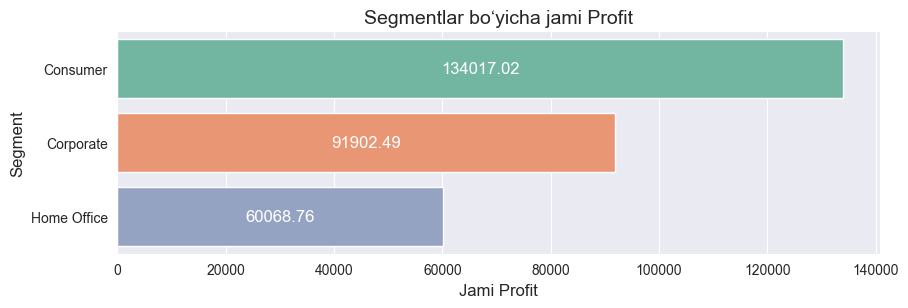

In [79]:
# 7. Qaysi mijoz segmenti eng yuqori foyda keltirmoqda?
profit_by_segment = (
    df.groupby('Segment')['Profit']
      .sum()
      .reset_index()
      .sort_values(by='Profit', ascending=False)
)

plt.figure(figsize=(10, 4), dpi=100)
sns.barplot(
    data=profit_by_segment,
    x='Profit',
    y='Segment',
    hue='Segment',
    palette='Set2',
    legend=False
)
plt.title("Segmentlar bo‘yicha jami Profit", fontsize=14)
plt.xlabel("Jami Profit", fontsize=12)
plt.ylabel("Segment", fontsize=12)

for bar in plt.gca().patches:
    w = bar.get_width()
    plt.gca().text(
        w / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.2f}",
        va='center', ha='center',
        color='white', fontsize=12
    )

plt.tight_layout(pad=4)
plt.show()

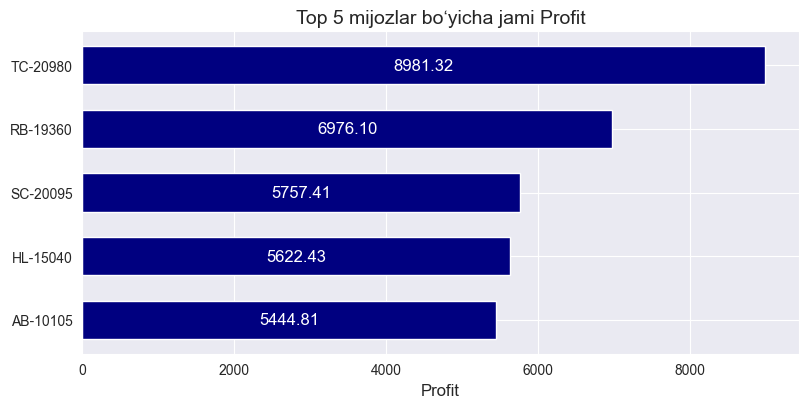

In [80]:
# 8. Qaysi beshta mijoz kompaniya sof foydasiga eng katta hissa qo‘shgan?
top5_profit = (
    df.groupby('Customer_ID')['Profit']
      .sum()
      .reset_index()
      .sort_values(by='Profit', ascending=False)
      .head(5)
)

plt.figure(figsize=(9, 5), dpi=100)
y = np.arange(len(top5_profit))
plt.barh(y, top5_profit['Profit'], height=0.6, color='navy')
plt.yticks(y, top5_profit['Customer_ID'])
plt.gca().invert_yaxis()
plt.title("Top 5 mijozlar bo‘yicha jami Profit", fontsize=14)
plt.xlabel("Profit", fontsize=12)
for i, v in enumerate(top5_profit['Profit']):
    plt.text(v / 2, i, f"{v:.2f}", va='center', ha='center', color='white', fontsize=12)
plt.tight_layout(pad=4)
plt.show()

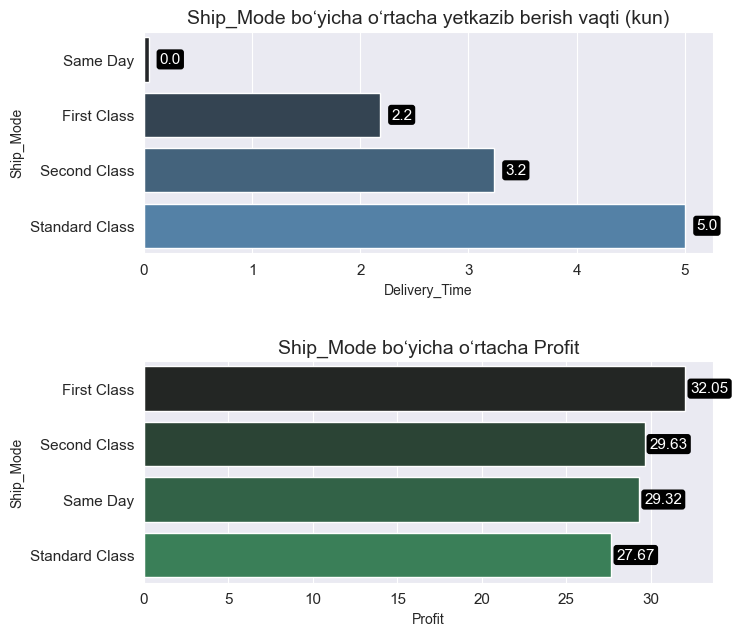

In [55]:
# 9. Qaysi Ship_Mode eng kam o‘rtacha yetkazib berish vaqtini ta’minlaydi va eng yuqori o‘rtacha Profit beradi?

ship = df['Ship_Date'].values.astype('datetime64[D]')
order = df['Order_Date'].values.astype('datetime64[D]')
df['Delivery_Time'] = (ship - order).astype(int)

stats_ship = (
    df.groupby('Ship_Mode')
      .agg(Delivery_Time=('Delivery_Time', 'mean'),
           Profit=('Profit', 'mean'))
      .reset_index()
)

plt.figure(figsize=(8, 7), dpi=100)

# ⬆️ Верхняя диаграмма: Delivery_Time
plt.subplot(2, 1, 1)
sns.barplot(
    data=stats_ship.sort_values('Delivery_Time'),
    x='Delivery_Time',
    y='Ship_Mode',
    hue='Ship_Mode',
    palette='dark:steelblue',
    legend=False
)
plt.title("Ship_Mode bo‘yicha o‘rtacha yetkazib berish vaqti (kun)", fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
for bar in plt.gca().patches:
    w = bar.get_width()
    plt.text(
        w + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.1f}",
        va='center',
        ha='left',
        fontsize=11,
        color='white',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', edgecolor='none')
    )

# ⬇️ Нижняя диаграмма: Profit
plt.subplot(2, 1, 2)
sns.barplot(
    data=stats_ship.sort_values('Profit', ascending=False),
    x='Profit',
    y='Ship_Mode',
    hue='Ship_Mode',
    palette='dark:seagreen',
    legend=False
)
plt.title("Ship_Mode bo‘yicha o‘rtacha Profit", fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
for bar in plt.gca().patches:
    w = bar.get_width()
    plt.text(
        w + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.2f}",
        va='center',
        ha='left',
        fontsize=11,
        color='white',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', edgecolor='none')
    )

plt.tight_layout(pad=3)
plt.show()

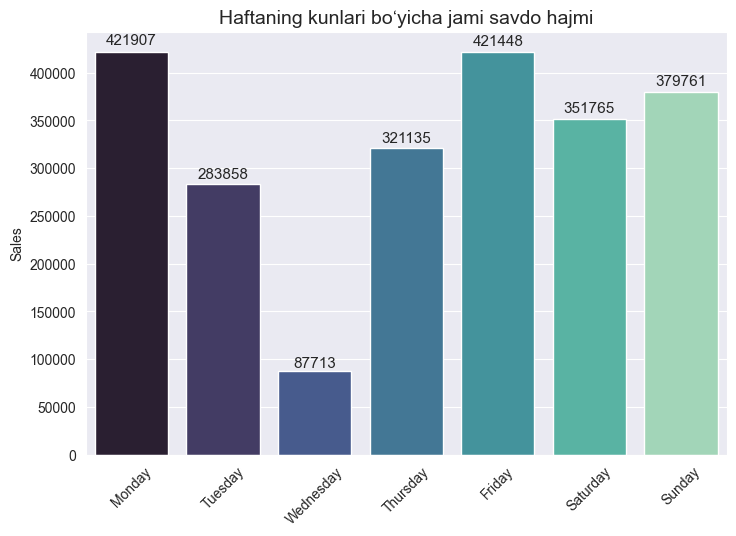

In [56]:
# 10. Haftaning kunlari bo‘yicha jami savdo hajmi

df['Weekday'] = df['Order_Date'].dt.day_name()

weekday_sales = (
    df.groupby('Weekday')['Sales']
      .sum()
      .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
      .reset_index()
)

plt.figure(figsize=(8, 6), dpi=100)
sns.barplot(
    data=weekday_sales,
    x='Weekday',
    y='Sales',
    hue='Weekday',
    palette='mako',
    legend=False
)
plt.title("Haftaning kunlari bo‘yicha jami savdo hajmi", fontsize=14)
plt.xlabel("")
plt.ylabel("Sales")
plt.xticks(rotation=45)
for bar in plt.gca().patches:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + h * 0.01,
        f"{h:.0f}",
        ha='center', va='bottom', fontsize=11
    )
plt.tight_layout(pad=3)
plt.show()

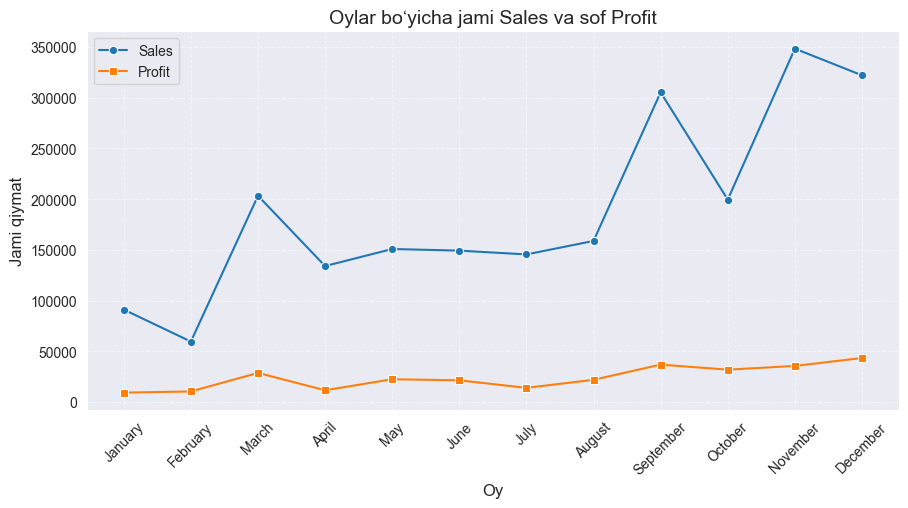

In [57]:
# 11. Qaysi oylar bo‘yicha jami savdo hajmi va sof foyda eng yuqori darajada bo‘ladi?
df['Order_Month'] = df['Order_Date'].dt.month_name()

monthly_stats = (
    df.groupby('Order_Month')
      .agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
      .reindex([
          'January','February','March','April','May','June',
          'July','August','September','October','November','December'
      ])
      .reset_index()
)

plt.figure(figsize=(10, 6), dpi=100)

sns.lineplot(
    data=monthly_stats,
    x='Order_Month',
    y='Sales',
    marker='o',
    label='Sales'
)
sns.lineplot(
    data=monthly_stats,
    x='Order_Month',
    y='Profit',
    marker='s',
    label='Profit'
)
plt.title("Oylar bo‘yicha jami Sales va sof Profit", fontsize=14)
plt.xlabel("Oy", fontsize=12)
plt.ylabel("Jami qiymat", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(pad=4)
plt.show()

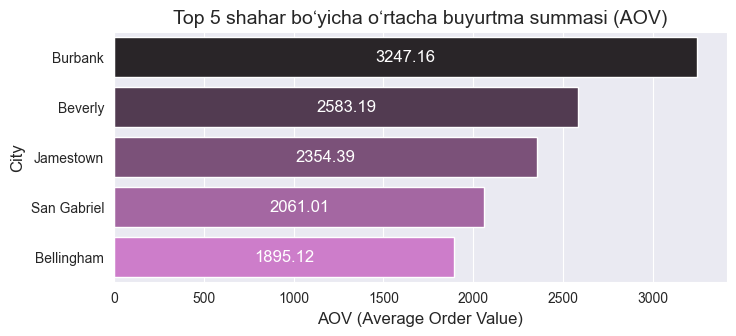

In [58]:
# 12. Qaysi shaharlar o‘rtacha buyurtma summasi (AOV) bo‘yicha yetakchi hisoblanadi?

order_counts_city = (
    df.groupby('City')['Order_ID']
      .nunique()
      .reset_index(name='Order_Count')
)

sales_city = (
    df.groupby('City')['Sales']
      .sum()
      .reset_index(name='Total_Sales')
)

aov_city = order_counts_city.merge(sales_city, on='City')
aov_city['AOV'] = aov_city['Total_Sales'] / aov_city['Order_Count']
top_aov = aov_city.sort_values(by='AOV', ascending=False).head(5)

plt.figure(figsize=(8, 4), dpi=100)
sns.barplot(
    data=top_aov,
    x='AOV',
    y='City',
    hue='City',
    palette='dark:orchid',
    legend=False
)
plt.title("Top 5 shahar bo‘yicha o‘rtacha buyurtma summasi (AOV)", fontsize=14)
plt.xlabel("AOV (Average Order Value)", fontsize=12)
plt.ylabel("City", fontsize=12)

for bar in plt.gca().patches:
    w = bar.get_width()
    plt.text(
        w / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.2f}",
        ha='center',
        va='center',
        color='white',
        fontsize=12
    )

plt.tight_layout(pad=3)
plt.show()

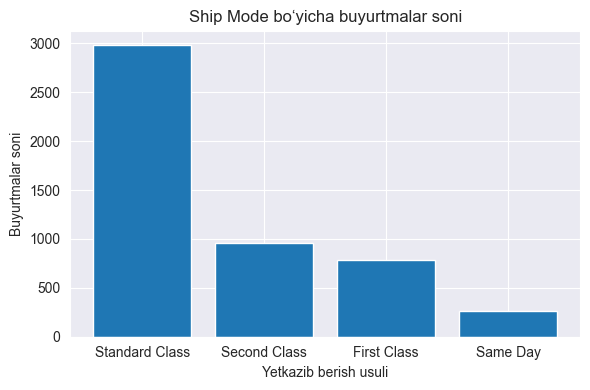

In [75]:
# Вопрос 13: Qaysi yetkazib berish usuli (Ship Mode) bo‘yicha buyurtmalar soni eng yuqori?

shipmode_counts = (
    df.groupby('Ship_Mode')['Order_ID']
    .nunique()
    .reset_index()
    .rename(columns={'Order_ID': 'Order_Count'})
    .sort_values(by='Order_Count', ascending=False)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(shipmode_counts['Ship_Mode'], shipmode_counts['Order_Count'])
plt.xlabel("Yetkazib berish usuli")
plt.ylabel("Buyurtmalar soni")
plt.title("Ship Mode bo‘yicha buyurtmalar soni")
plt.tight_layout()
plt.show()

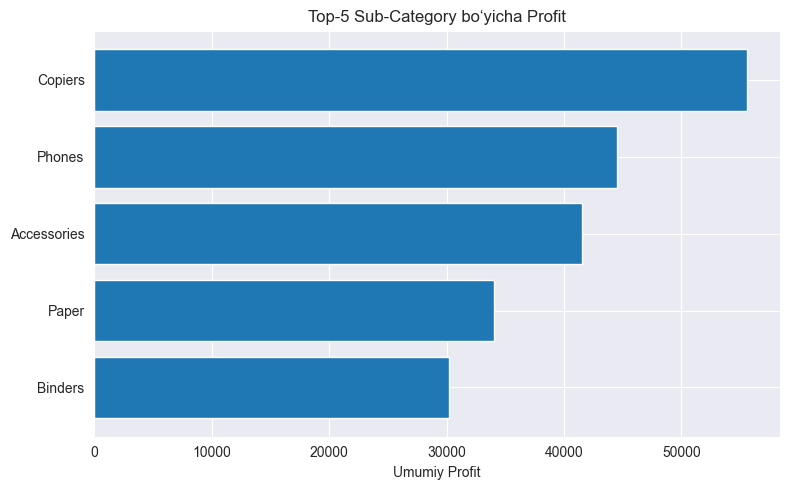

In [64]:
# Вопрос 14: Qaysi beshta sub-kategoriya (Sub-Category) mahsulotlari eng yuqori foydani ta’minlaydi?

profit_by_subcat = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .reset_index()
    .sort_values(by='Profit', ascending=False)
    .head(5)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(profit_by_subcat['Sub-Category'], profit_by_subcat['Profit'])
plt.xlabel("Umumiy Profit")
plt.title("Top-5 Sub-Category bo‘yicha Profit")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

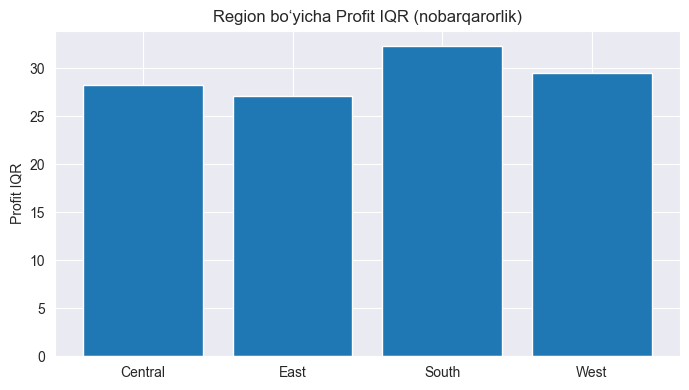

In [68]:
# Вопрос 15: Qaysi hududlarda (Region) Profit qiymatlari eng nobarqaror? (Ya'ni, IQR qiymati eng katta bo‘lgan hududlar qanday?)

iqr_by_region = (
    df.groupby('Region')['Profit']
    .agg(lambda x: x.quantile(0.75) - x.quantile(0.25))
    .reset_index()
    .rename(columns={'Profit': 'IQR'})
)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(iqr_by_region['Region'], iqr_by_region['IQR'])
plt.ylabel("Profit IQR")
plt.title("Region bo‘yicha Profit IQR (nobarqarorlik)")
plt.tight_layout()
plt.show()

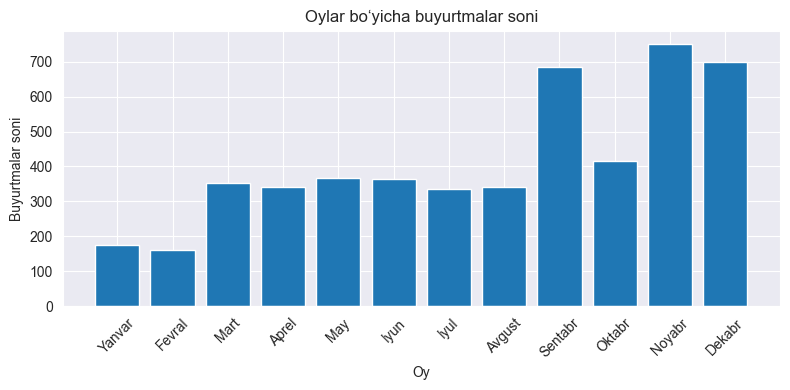

In [74]:
# Вопрос 16: Qaysi oyda (oylar kesimida) eng ko‘p buyurtma (Order) amalga oshirilgan?

df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%Y-%m-%d', errors='coerce')
df['Order_Month'] = df['Order_Date'].dt.month

orders_by_month = (
    df.groupby('Order_Month')['Order_ID']
    .nunique()
    .reset_index()
    .rename(columns={'Order_ID': 'Order_Count'})
)

# Названия месяцев на узбекском (можно заменить на русском или английском при необходимости)
month_names = ['Yanvar', 'Fevral', 'Mart', 'Aprel', 'May', 'Iyun',
               'Iyul', 'Avgust', 'Sentabr', 'Oktabr', 'Noyabr', 'Dekabr']
orders_by_month['Month_Name'] = orders_by_month['Order_Month'].apply(lambda x: month_names[x - 1])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(orders_by_month['Month_Name'], orders_by_month['Order_Count'])
plt.xlabel("Oy")
plt.ylabel("Buyurtmalar soni")
plt.title("Oylar bo‘yicha buyurtmalar soni")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()